In [228]:
import pandas as pd
import numpy as np
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import VotingClassifier
from xgboost import XGBClassifier
import lightgbm as lgb
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

In [229]:
# Data load 
df = pd.read_csv('train.csv')
print(df.head())

         ID  Gender  Age Region_Code     Occupation Channel_Code  Vintage  \
0  NNVBBKZB  Female   73       RG268          Other           X3       43   
1  IDD62UNG  Female   30       RG277       Salaried           X1       32   
2  HD3DSEMC  Female   56       RG268  Self_Employed           X3       26   
3  BF3NC7KV    Male   34       RG270       Salaried           X1       19   
4  TEASRWXV  Female   30       RG282       Salaried           X1       33   

  Credit_Product  Avg_Account_Balance Is_Active  Is_Lead  
0             No              1045696        No        0  
1             No               581988        No        0  
2             No              1484315       Yes        0  
3             No               470454        No        0  
4             No               886787        No        0  


In [230]:
print("Data Shape:", df.shape)

Data Shape: (245725, 11)


In [231]:
print("\n---Missing Values---")
print(df.isnull().sum())


---Missing Values---
ID                         0
Gender                     0
Age                        0
Region_Code                0
Occupation                 0
Channel_Code               0
Vintage                    0
Credit_Product         29325
Avg_Account_Balance        0
Is_Active                  0
Is_Lead                    0
dtype: int64


In [232]:
df.describe()

,Age,Vintage,Avg_Account_Balance,Is_Lead
count,245725.000000,245725.000000,2.457250e+05,245725.000000
mean,43.856307,46.959141,1.128403e+06,0.237208
std,14.828672,32.353136,8.529364e+05,0.425372
min,23.000000,7.000000,2.079000e+04,0.000000
25%,30.000000,20.000000,6.043100e+05,0.000000
50%,43.000000,32.000000,8.946010e+05,0.000000
75%,54.000000,73.000000,1.366666e+06,0.000000
max,85.000000,135.000000,1.035201e+07,1.000000


In [233]:
df.columns

Index(['ID', 'Gender', 'Age', 'Region_Code', 'Occupation', 'Channel_Code',
       'Vintage', 'Credit_Product', 'Avg_Account_Balance', 'Is_Active',
       'Is_Lead'],
      dtype='object')

In [234]:
# 1. fill missing values with unknown
df['Credit_Product'] = df['Credit_Product'].fillna('Unknown')

# 2. Check missing values
print("Credit_Product Missing Values After Fix:", df['Credit_Product'].isnull().sum())

# 3. check target values balance
print("\n--- Lead Balance (Target Variable) ---")
print(df['Is_Lead'].value_counts(normalize=True) * 100)

Credit_Product Missing Values After Fix: 0

--- Lead Balance (Target Variable) ---
Is_Lead
0    76.279174
1    23.720826
Name: proportion, dtype: float64


In [235]:
if 'Credit_Product' in df.columns:
    df['Credit_Product'] = df['Credit_Product'].replace('Unknown', 'No')

In [236]:
# 1. Log Transformation of Avg account balance
df['Avg_Account_Balance_log'] = np.log1p(df['Avg_Account_Balance'])

In [237]:
print("\n--- Lead Balance (Target Variable) ---")
print(df['Is_Lead'].value_counts(normalize=True) * 100)


--- Lead Balance (Target Variable) ---
Is_Lead
0    76.279174
1    23.720826
Name: proportion, dtype: float64


<Axes: >

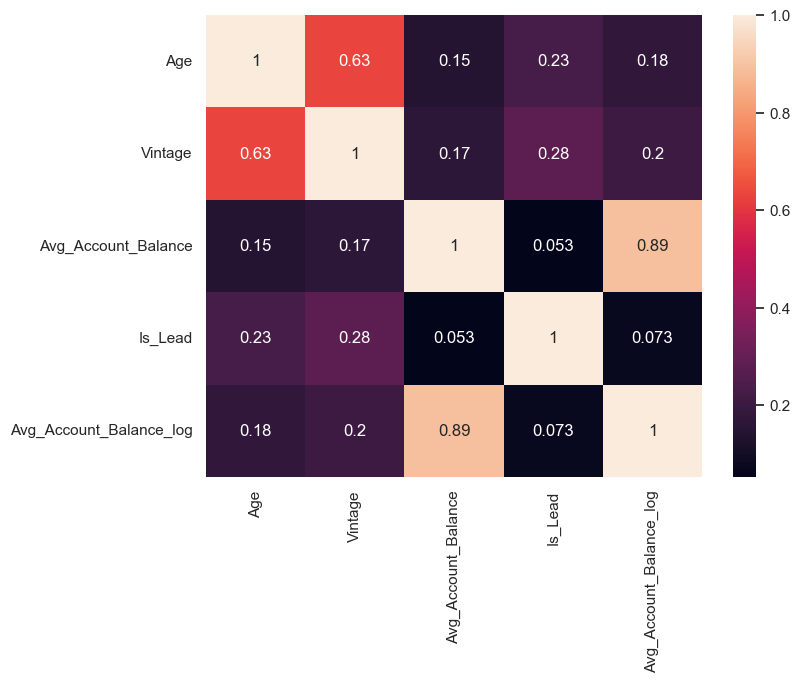

In [238]:
plt.figure(figsize = (8,6))
sns.heatmap(df.corr(numeric_only = True), annot = True)

In [239]:
# Categorical Conversion Matrix (Label / Target Conversion for Region
df['Region_Code'] = df['Region_Code'].astype('category').cat.codes

In [240]:
# conversion of text columns into numeric features (One-HOt Encoding)
df['Gender_Male'] = np.where(df['Gender'] == 'Male', 1, 0)

df['Occupation_Other'] = np.where(df['Occupation'] == 'Other', 1, 0)
df['Occupation_Salaried'] = np.where(df['Occupation'] == 'Salaried', 1, 0)
df['Occupation_Self_Employed'] = np.where(df['Occupation'] == 'Self_Employed', 1, 0)

df['Channel_Code_X2'] = np.where(df['Channel_Code'] == 'X2', 1, 0)
df['Channel_Code_X3'] = np.where(df['Channel_Code'] == 'X3', 1, 0)
df['Channel_Code_X4'] = np.where(df['Channel_Code'] == 'X4', 1, 0)
df['Credit_Product_Unknown'] = np.where(df['Credit_Product'] == 'Unknown', 1, 0)
df['Credit_Product_Yes'] = np.where(df['Credit_Product'] == 'Yes', 1, 0)

df['Is_Active_Yes'] = np.where(df['Is_Active'] == 'Yes', 1, 0)

In [241]:
df

,ID,Gender,Age,Region_Code,Occupation,Channel_Code,Vintage,Credit_Product,Avg_Account_Balance,Is_Active,...,Gender_Male,Occupation_Other,Occupation_Salaried,Occupation_Self_Employed,Channel_Code_X2,Channel_Code_X3,Channel_Code_X4,Credit_Product_Unknown,Credit_Product_Yes,Is_Active_Yes
0,NNVBBKZB,Female,73,18,Other,X3,43,No,1045696,No,...,0,1,0,0,0,1,0,0,0,0
1,IDD62UNG,Female,30,27,Salaried,X1,32,No,581988,No,...,0,0,1,0,0,0,0,0,0,0
2,HD3DSEMC,Female,56,18,Self_Employed,X3,26,No,1484315,Yes,...,0,0,0,1,0,1,0,0,0,1
3,BF3NC7KV,Male,34,20,Salaried,X1,19,No,470454,No,...,1,0,1,0,0,0,0,0,0,0
4,TEASRWXV,Female,30,32,Salaried,X1,33,No,886787,No,...,0,0,1,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
245720,BPAWWXZN,Male,51,34,Self_Employed,X3,109,No,1925586,No,...,1,0,0,1,0,1,0,0,0,0
245721,HFNB7JY8,Male,27,18,Salaried,X1,15,No,862952,Yes,...,1,0,1,0,0,0,0,0,0,1
245722,GEHAUCWT,Female,26,31,Salaried,X1,13,No,670659,No,...,0,0,1,0,0,0,0,0,0,0
245723,GE7V8SAH,Female,28,23,Salaried,X1,31,No,407504,No,...,0,0,1,0,0,0,0,0,0,0


In [242]:
# STRICT FEATURE ALIGNMENT & TARGET SEPARATION
expected_features = [
    'Age', 'Region_Code', 'Vintage', 'Gender_Male', 
    'Occupation_Other', 'Occupation_Salaried', 'Occupation_Self_Employed', 
    'Channel_Code_X2', 'Channel_Code_X3', 'Channel_Code_X4', 
    'Credit_Product_Unknown', 'Credit_Product_Yes', 'Is_Active_Yes', 
    'Avg_Account_Balance_log'
]

X = df[expected_features]
y = df['Is_Lead'] # Target Flag Variable

In [243]:
X

,Age,Region_Code,Vintage,Gender_Male,Occupation_Other,Occupation_Salaried,Occupation_Self_Employed,Channel_Code_X2,Channel_Code_X3,Channel_Code_X4,Credit_Product_Unknown,Credit_Product_Yes,Is_Active_Yes,Avg_Account_Balance_log
0,73,18,43,0,1,0,0,0,1,0,0,0,0,13.860194
1,30,27,32,0,0,1,0,0,0,0,0,0,0,13.274207
2,56,18,26,0,0,0,1,0,1,0,0,0,1,14.210465
3,34,20,19,1,0,1,0,0,0,0,0,0,0,13.061456
4,30,32,33,0,0,1,0,0,0,0,0,0,0,13.695361
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
245720,51,34,109,1,0,0,1,0,1,0,0,0,0,14.470741
245721,27,18,15,1,0,1,0,0,0,0,0,0,1,13.668116
245722,26,31,13,0,0,1,0,0,0,0,0,0,0,13.416018
245723,28,23,31,0,0,1,0,0,0,0,0,0,0,12.917808


In [244]:
# STRATIFIED TRAIN-TEST SPLIT (Distribution Maintenance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"📊 Training Matrix Elements: {X_train.shape[0]} Rows | Test Elements: {X_test.shape[0]} Rows")

📊 Training Matrix Elements: 196580 Rows | Test Elements: 49145 Rows


In [245]:
# 1. Fit standard scaler completely on numbers
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. Over-sampling using SMOTE to balance targets perfectly
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)

print(f"⚖️ SMOTE Complete! Balanced Dataset Shape: {X_train_balanced.shape[0]} Rows")

⚖️ SMOTE Complete! Balanced Dataset Shape: 299900 Rows


In [246]:
# STEP 6: REGULARIZED ANTI-BIAS TRIO ENSEMBLE DEFINITION
xgb_tuned = XGBClassifier(
    n_estimators=100, learning_rate=0.05, max_depth=4, 
    min_child_weight=5, reg_lambda=15, random_state=42
)

lgb_tuned = lgb.LGBMClassifier(
    n_estimators=100, learning_rate=0.05, max_depth=4, 
    reg_alpha=5, random_state=42, verbose=-1
)

rf_tuned = RandomForestClassifier(
    n_estimators=100, max_depth=7, random_state=42, n_jobs=-1
)

trio_voting_ensemble = VotingClassifier(
    estimators=[('xgb', xgb_tuned), ('lgb', lgb_tuned), ('rf', rf_tuned)], 
    voting='soft'
)

In [247]:
# Train the model
print("🚀 Training the Enterprise Ensemble Architecture... Please wait...")
trio_voting_ensemble.fit(X_train_balanced, y_train_balanced)

🚀 Training the Enterprise Ensemble Architecture... Please wait...


,estimators,"[('xgb', ...), ('lgb', ...), ...]"
,voting,'soft'
,weights,None
,n_jobs,None
,flatten_transform,True
,verbose,False
,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None


In [248]:
# Predictions & Metrics Check
predictions = trio_voting_ensemble.predict(X_test_scaled)
print("\n🎯 --- MODEL ROBUSTNESS REPORT --- 🎯")
print(f"Global Accuracy: {accuracy_score(y_test, predictions) * 100:.2f}%")
print("\nClassification Matrix:\n", classification_report(y_test, predictions))


🎯 --- MODEL ROBUSTNESS REPORT --- 🎯
Global Accuracy: 71.42%

Classification Matrix:
               precision    recall  f1-score   support

           0       0.88      0.72      0.79     37487
           1       0.44      0.69      0.54     11658

    accuracy                           0.71     49145
   macro avg       0.66      0.71      0.66     49145
weighted avg       0.78      0.71      0.73     49145



In [249]:
# Export artifact for streamlit app
joblib.dump(trio_voting_ensemble, 'final_trio_ensemble_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

print("💾 Success! 'final_trio_ensemble_model.pkl' and 'scaler.pkl' are exported.")

💾 Success! 'final_trio_ensemble_model.pkl' and 'scaler.pkl' are exported.


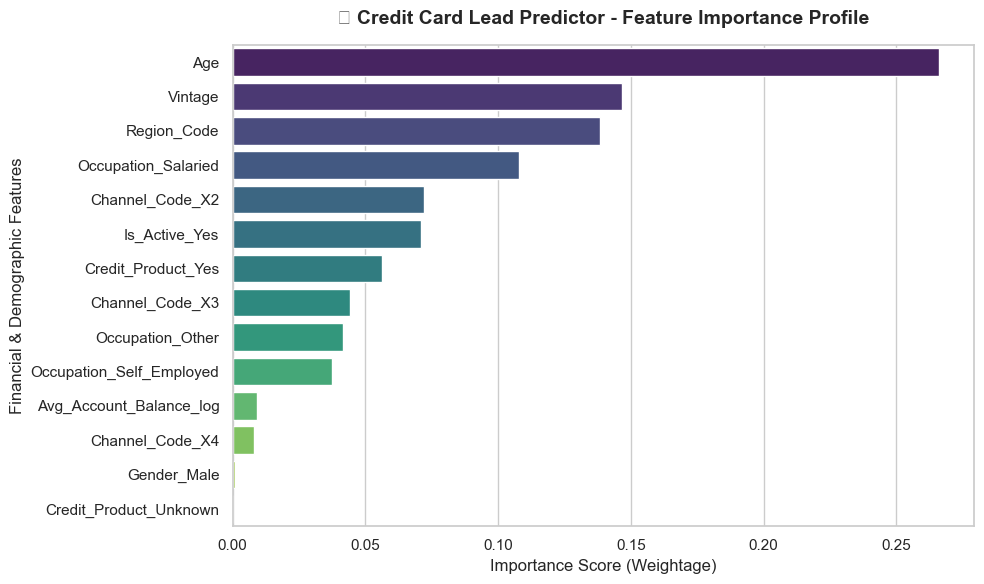

In [251]:
import matplotlib.pyplot as plt
import seaborn as sns

xgb_model = trio_voting_ensemble.named_estimators_['xgb']

importance_dict = {
    'Feature': expected_features,
    'Importance': xgb_model.feature_importances_
}

importance_df = pd.DataFrame(importance_dict).sort_values(by='Importance', ascending=False)

# 4. Premium Visualization Setup
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# draw a horizontal barplot
sns.barplot(x='Importance', y='Feature', data=importance_df, hue='Feature', palette='viridis', legend=False)
# set the titles and lables of graph
plt.title('🎯 Credit Card Lead Predictor - Feature Importance Profile', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Importance Score (Weightage)', fontsize=12)
plt.ylabel('Financial & Demographic Features', fontsize=12)
plt.tight_layout()

plt.show()